#### k-Means
- 대표적인 군집 알고리즘으로 군집의 중심을 찾는 작업
- 클러스터(cluster) : 군집
- 클러스터링 : 군집화 하는 작업

In [1]:
import numpy as np

In [2]:
fruits = np.load("../Data/fruits.npy")
fruits.shape

(300, 100, 100)

In [ ]:
# 3차원 데이터를 2차원 데이터로 변경
fruits_2d = fruits.reshape(-1, 100*100)
fruits_2d.shape

(300, 10000)

#### k-Means Model

In [9]:
from sklearn.cluster import KMeans

In [10]:
km = KMeans(
        n_clusters=3
)
km.fit(fruits_2d)

c:\Users\tjoeun\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [11]:
# 군집화된 Label 출력
km.labels_

array([0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], d

----
### 첫번째 클러스터 확인하기

In [13]:
import matplotlib.pyplot as plt

In [16]:
def draw_fruits(arr, ratio=1):# ratio : 해상도
    n = len(arr) # n: 샘플갯수
    # 한 줄에 10개씩 이미지를 그린다.
    rows = int(np.ceil(n/10)) # 올림처리
    # 행이 1개이면 열 갯수가 샘플갯수 그렇지 않으면 10개
    cols = n if rows < 2 else 10
    fig, axs = plt.subplots(
                rows,
                cols,
                figsize= (cols*ratio, rows*ratio),
                squeeze = False
    )
    for i in range(rows):
        for j in range(cols):
            if i*10+j < n:
                axs[i,j].imshow(arr[i*10+j], cmap='gray')
            axs[i,j].axis('off')
    
    plt.show()

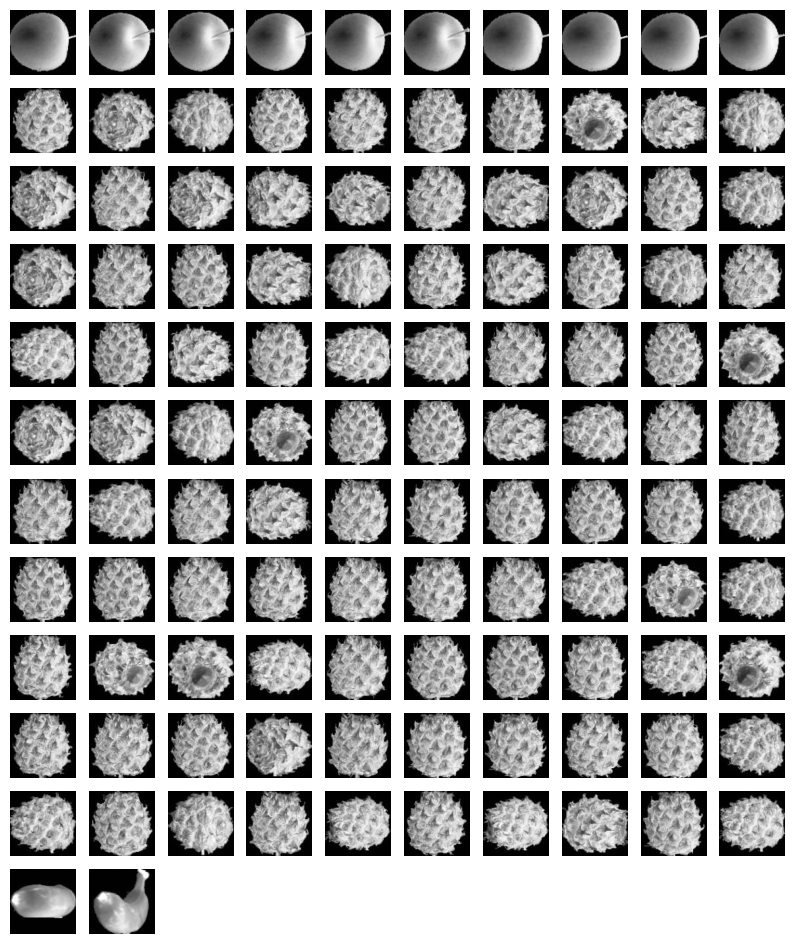

In [19]:
draw_fruits(fruits[km.labels_ == 2])

----
### 최적의 k 찾기
#### Elbow Method(최적의 군집수 구하기)

c:\Users\tjoeun\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\tjoeun\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\tjoeun\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\tjoeun\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

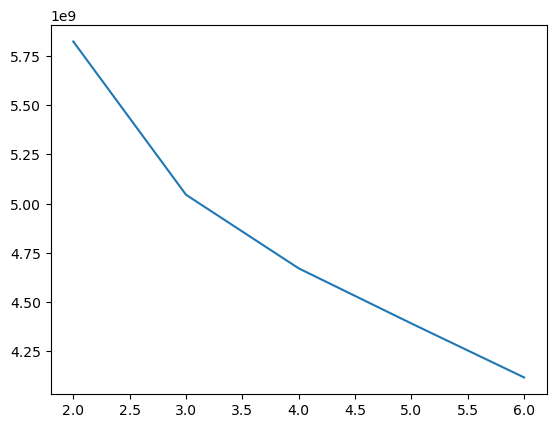

In [ ]:
inertia = []
for k in range(2, 7):
    km = KMeans(
        n_clusters=k
    )
    km.fit(fruits_2d)
    inertia.append(km.inertia_)

plt.plot(
    range(2, 7),
    inertia
)

plt.show()
